# 1. dynnode2vec

1. **Snapshots:** Try `n_snapshots=4` vs `12`. How does mean link-prediction AUC change?
2. **Biased walks:** Set `p=0.5, q=2` (BFS-like) vs `p=2, q=0.5` (DFS-like). Compare t-SNE plots.

## Word2Vec

In [1]:
from collections import defaultdict

class _WordVectors:
    def __init__(self, model):
        self._model = model

    @property
    def index_to_key(self):
        return list(self._model.index2word)

    @property
    def key_to_index(self):
        return dict(self._model.word2index)

    def __contains__(self, key):
        return key in self._model.word2index

    def __getitem__(self, key):
        return self._model.syn0[self._model.word2index[key]]

    def __setitem__(self, key, value):
        vector = np.asarray(value, dtype=float)
        if vector.shape != (self._model.vector_size,):
            raise ValueError(f'Expected vector of shape {(self._model.vector_size,)}, got {vector.shape}')
        if key not in self._model.word2index:
            self._model._add_word(key)
        self._model.syn0[self._model.word2index[key]] = vector


class Word2Vec:
    def __init__(
        self,
        sentences=None,
        size=100,
        vector_size=100,
        seed=0,
        workers=4,
        window=5,
        negative=5,
        alpha=0.025,
        min_count=1,
        sg=1,
        iter=5,
        num_threads=4,
        epochs=5,
    ):
        self.sentences = list(sentences) if sentences is not None else []
        self.size = vector_size if vector_size is not None else size
        self.vector_size = self.size
        self.window = window
        self.negative = negative
        self.alpha = alpha
        self.iter = iter
        self.epochs = epochs
        self.min_count = min_count
        self.sg = sg
        self.num_threads = num_threads
        self.seed = seed
        self.workers = workers
        self.rng = np.random.default_rng(seed)
        self.vocab = defaultdict(int)
        self.index2word = []
        self.word2index = {}
        self.syn0 = None
        self.syn1neg = None
        self.corpus_count = 0
        self.wv = _WordVectors(self)

        if self.sentences:
            self.build_vocab(self.sentences)
            self.train(self.sentences, epochs=self.epochs)

    def _random_vector(self):
        return self.rng.uniform(-0.5 / self.vector_size, 0.5 / self.vector_size, self.vector_size)

    def _add_word(self, word):
        if word in self.word2index:
            return
        self.word2index[word] = len(self.index2word)
        self.index2word.append(word)
        if self.syn0 is not None:
            self.syn0 = np.vstack([self.syn0, self._random_vector()])
            self.syn1neg = np.vstack([self.syn1neg, np.zeros(self.vector_size, dtype=float)])

    def build_vocab(self, sentences=None, update=False):
        if sentences is not None:
            self.sentences = list(sentences)

        if not update:
            self.vocab = defaultdict(int)

        for sentence in self.sentences:
            for word in sentence:
                self.vocab[word] += 1

        previous_vectors = None
        if update and self.syn0 is not None and self.index2word:
            previous_vectors = {word: self.syn0[idx].copy() for word, idx in self.word2index.items()}

        self.index2word = [word for word, count in self.vocab.items() if count >= self.min_count]
        self.word2index = {word: idx for idx, word in enumerate(self.index2word)}
        self.corpus_count = len(self.sentences)
        self.init_weights()

        if previous_vectors:
            for word, vec in previous_vectors.items():
                if word in self.word2index:
                    self.syn0[self.word2index[word]] = vec

        return self

    def init_weights(self):
        vocab_size = len(self.index2word)
        self.syn0 = self.rng.uniform(-0.5 / self.vector_size, 0.5 / self.vector_size, (vocab_size, self.vector_size))
        self.syn1neg = np.zeros((vocab_size, self.vector_size), dtype=float)

    def train(self, sentences=None, total_examples=None, epochs=None):
        if sentences is not None:
            self.sentences = list(sentences)

        if self.syn0 is None or len(self.index2word) != len(self.word2index):
            self.build_vocab(self.sentences, update=False)

        self.train_process(self.sentences, epochs=epochs if epochs is not None else self.epochs)
        return self

    def train_process(self, sentences=None, epochs=None):
        sentences = self.sentences if sentences is None else sentences
        epochs = self.epochs if epochs is None else epochs
        for _ in range(epochs):
            for sentence in sentences:
                self.train_epoch(sentence)

    def train_epoch(self, sentence):
        for i, word in enumerate(sentence):
            if word not in self.word2index:
                continue
            word_idx = self.word2index[word]
            start = max(0, i - self.window)
            end = min(len(sentence), i + self.window + 1)
            for j in range(start, end):
                if j == i:
                    continue
                context_word = sentence[j]
                if context_word in self.word2index:
                    context_idx = self.word2index[context_word]
                    self.train_pair(word_idx, context_idx)

    def train_pair(self, word_idx, context_idx):
        l1 = self.syn0[word_idx]
        l2 = self.syn1neg[context_idx]
        product = np.dot(l1, l2)
        g = self.alpha * (1 - product)
        self.syn0[word_idx] += g * l2
        self.syn1neg[context_idx] += g * l1

    def get_embeddings(self):
        return {word: self.syn0[idx] for word, idx in self.word2index.items()}

## Setup

In [2]:
import csv
from collections import defaultdict
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from sklearn.manifold import TSNE

ROOT = Path('.').resolve()
DATA_DIR = ROOT / 'data' / 'dblp_mini'
WORK_DIR = ROOT / 'temp_dynnode2vec_nb'

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 4)

## DBLP temporal snapshots

In [9]:
def load_dblp_snapshots(data_dir: Path = DATA_DIR, n_snapshots: int = 8):
    with open(data_dir / 'authors.csv', encoding='utf-8') as f:
        authors = [row['name'] for row in csv.DictReader(f)]

    edges = []
    for fname in ('edges_static.csv', 'edges_dynamic.csv'):
        with open(data_dir / fname, encoding='utf-8') as f:
            for row in csv.DictReader(f):
                edges.append((int(row['u']), int(row['v']), int(row['year'])))

    edges.sort(key=lambda x: x[2])
    years = sorted({y for _, _, y in edges})
    if len(years) <= n_snapshots:
        cut_years = years
    else:
        idx = np.linspace(0, len(years) - 1, n_snapshots, dtype=int)
        cut_years = [years[i] for i in idx]

    n = len(authors)
    graphs = []
    for y_cut in cut_years:
        g = nx.Graph()
        g.add_nodes_from(range(n))
        for u, v, y in edges:
            if y <= y_cut:
                g.add_edge(u, v)
        graphs.append(g)
    return authors, graphs, cut_years

authors, graphs_4, years_4 = load_dblp_snapshots(n_snapshots=4)
authors, graphs_12, years_12 = load_dblp_snapshots(n_snapshots=12)
print(f'Authors: {len(authors)} | Snapshots: {len(graphs_4)} / {len(graphs_12)}')

Authors: 59 | Snapshots: 4 / 12


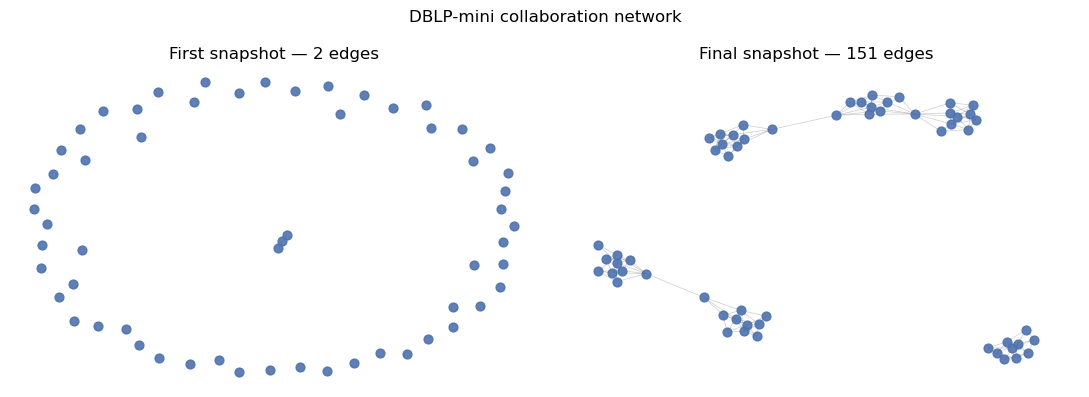

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, idx, title in zip(axes, [0, len(graphs) - 1], ['First snapshot', 'Final snapshot']):
    g = graphs[idx]
    pos = nx.spring_layout(g, seed=42)
    nx.draw_networkx_nodes(g, pos, node_size=40, node_color='#4C72B0', alpha=0.9, ax=ax)
    nx.draw_networkx_edges(g, pos, alpha=0.2, width=0.5, ax=ax)
    ax.set_title(f'{title} — {g.number_of_edges()} edges')
    ax.axis('off')
plt.suptitle('DBLP-mini collaboration network')
plt.tight_layout()
plt.show()

## Evolving nodes

In [5]:
def get_delta_nodes(g_prev: nx.Graph, g_cur: nx.Graph) -> set[int]:
    delta_edges = set(map(tuple, g_cur.edges)) ^ set(map(tuple, g_prev.edges))
    return {v for edge in delta_edges for v in edge}

# Example: change from G_0 → G_1
if len(graphs) >= 2:
    d = get_delta_nodes(graphs[0], graphs[1])
    print(f'|ΔV_1| = {len(d)}', 'sample:', sorted(d)[:8])

|ΔV_1| = 7 sample: [1, 3, 4, 5, 7, 8, 9]


## node2vec random walks

In [6]:
class Node2VecWalks:
    def __init__(self, graph: nx.Graph, p: float = 1.0, q: float = 1.0, seed: int = 42):
        self.graph = graph
        self.p, self.q = p, q
        self.rng = np.random.default_rng(seed)
        self.neighbors = {n: sorted(graph.neighbors(n)) for n in graph.nodes()}

    def _norm_probs(self, weights):
        s = sum(weights)
        return None if s <= 0 else np.array(weights, float) / s

    def _step(self, prev, cur):
        nbrs = self.neighbors[cur]
        if not nbrs:
            return None
        if prev is None:
            probs = self._norm_probs([1.0] * len(nbrs))
        else:
            w = []
            for nxt in nbrs:
                if nxt == prev:
                    w.append(1.0 / self.p)
                elif self.graph.has_edge(prev, nxt):
                    w.append(1.0)
                else:
                    w.append(1.0 / self.q)
            probs = self._norm_probs(w)
        return None if probs is None else int(self.rng.choice(nbrs, p=probs))

    def generate(self, nodes: Iterable[int], walk_length: int, num_walks: int):
        walks = []
        for source in nodes:
            for _ in range(num_walks):
                walk = [str(source)]
                if not self.neighbors[source]:
                    walks.append(walk)
                    continue
                nxt = self._step(None, source)
                if nxt is None:
                    walks.append(walk)
                    continue
                walk.append(str(nxt))
                while len(walk) < walk_length:
                    nxt = self._step(int(walk[-2]), int(walk[-1]))
                    if nxt is None:
                        break
                    walk.append(str(nxt))
                walks.append(walk)
        return walks

## dynnode2vec

In [7]:
def _load_initial_vectors(path, dim):
    out = {}
    with open(path, encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= dim + 1:
                out[parts[0]] = np.array(parts[1:dim + 1], float)
    return out


def _apply_initial_vectors(model, path):
    for word, vec in _load_initial_vectors(path, model.vector_size).items():
        if word in model.wv:
            model.wv[word] = vec


def dynnode2vec(
    graphs,
    dimensions=16,
    walk_length=40,
    num_walks=10,
    p=1.0,
    q=1.0,
    window=5,
    epochs=5,
    seed=42,
    work_dir=WORK_DIR,
    verbose=True,
):
    work_dir = Path(work_dir)
    work_dir.mkdir(parents=True, exist_ok=True)

    w0 = Node2VecWalks(graphs[0], p=p, q=q, seed=seed)
    walks0 = w0.generate(graphs[0].nodes(), walk_length, num_walks)
    model = Word2Vec(
        sentences=walks0,
        vector_size=dimensions,
        window=window,
        min_count=0,
        sg=1,
        workers=1,
        seed=seed,
        epochs=epochs,
    )
    with open(work_dir / 'wv_0.emb', 'w', encoding='utf-8') as f:
        for word in model.wv.index_to_key:
            f.write(f"{word} {' '.join(map(str, model.wv[word]))}\n")
    if verbose:
        print(f't=0 | edges={graphs[0].number_of_edges()} walks={len(walks0)}')

    for t in range(1, len(graphs)):
        delta = get_delta_nodes(graphs[t - 1], graphs[t])
        wt = Node2VecWalks(graphs[t], p=p, q=q, seed=seed + t)
        walks = wt.generate(delta, walk_length, num_walks) if delta else []
        prev_emb = work_dir / f'wv_{t - 1}.emb'

        if walks:
            model.build_vocab(walks, update=True)
            if prev_emb.exists():
                _apply_initial_vectors(model, prev_emb)
            model.train(walks, total_examples=model.corpus_count, epochs=model.epochs)
        elif prev_emb.exists():
            _apply_initial_vectors(model, prev_emb)

        with open(work_dir / f'wv_{t}.emb', 'w', encoding='utf-8') as f:
            for word in model.wv.index_to_key:
                f.write(f"{word} {' '.join(map(str, model.wv[word]))}\n")

        if verbose:
            print(f't={t} | |ΔV|={len(delta)} walks={len(walks)} edges={graphs[t].number_of_edges()}')

    return model

## Train

In [10]:
DIM = 16
WALK_LENGTH = 40
NUM_WALKS = 8

model_4 = dynnode2vec(graphs_4, dimensions=DIM, walk_length=WALK_LENGTH,
                      num_walks=NUM_WALKS, p=1.0, q=1.0, work_dir=WORK_DIR / 'snap4')
model_12 = dynnode2vec(graphs_12, dimensions=DIM, walk_length=WALK_LENGTH,
                       num_walks=NUM_WALKS, p=1.0, q=1.0, work_dir=WORK_DIR / 'snap12')
model_bfs = dynnode2vec(graphs_12, dimensions=DIM, walk_length=WALK_LENGTH,
                        num_walks=NUM_WALKS, p=0.5, q=2.0, work_dir=WORK_DIR / 'bfs')
model_dfs = dynnode2vec(graphs_12, dimensions=DIM, walk_length=WALK_LENGTH,
                        num_walks=NUM_WALKS, p=2.0, q=0.5, work_dir=WORK_DIR / 'dfs')

t=0 | edges=2 walks=472
t=1 | |ΔV|=29 walks=232 edges=34
t=2 | |ΔV|=42 walks=336 edges=94
t=3 | |ΔV|=40 walks=320 edges=151
t=0 | edges=2 walks=472
t=1 | |ΔV|=5 walks=40 edges=5
t=2 | |ΔV|=7 walks=56 edges=11
t=3 | |ΔV|=2 walks=16 edges=12
t=4 | |ΔV|=25 walks=200 edges=34
t=5 | |ΔV|=21 walks=168 edges=48
t=6 | |ΔV|=16 walks=128 edges=58
t=7 | |ΔV|=30 walks=240 edges=83
t=8 | |ΔV|=38 walks=304 edges=109
t=9 | |ΔV|=21 walks=168 edges=123
t=10 | |ΔV|=23 walks=184 edges=139
t=11 | |ΔV|=18 walks=144 edges=151
t=0 | edges=2 walks=472
t=1 | |ΔV|=5 walks=40 edges=5
t=2 | |ΔV|=7 walks=56 edges=11
t=3 | |ΔV|=2 walks=16 edges=12
t=4 | |ΔV|=25 walks=200 edges=34
t=5 | |ΔV|=21 walks=168 edges=48
t=6 | |ΔV|=16 walks=128 edges=58
t=7 | |ΔV|=30 walks=240 edges=83
t=8 | |ΔV|=38 walks=304 edges=109
t=9 | |ΔV|=21 walks=168 edges=123
t=10 | |ΔV|=23 walks=184 edges=139
t=11 | |ΔV|=18 walks=144 edges=151
t=0 | edges=2 walks=472
t=1 | |ΔV|=5 walks=40 edges=5
t=2 | |ΔV|=7 walks=56 edges=11
t=3 | |ΔV|=2 walks=

## Evaluate by link prediction

In [11]:
from sklearn.metrics import roc_auc_score

def link_prediction_auc(graphs, model):
    scores = []
    for t in range(len(graphs) - 1):
        g_cur, g_next = graphs[t], graphs[t + 1]
        new_edges = set(map(tuple, g_next.edges)) - set(map(tuple, g_cur.edges))
        if not new_edges:
            continue
        nodes = list(g_cur.nodes())
        existing = set(map(tuple, g_cur.edges))
        rng = np.random.default_rng(t)
        neg = []
        while len(neg) < min(len(new_edges), 200):
            u, v = rng.integers(0, len(nodes), 2)
            if u == v:
                continue
            a, b = min(u, v), max(u, v)
            if (a, b) not in existing:
                neg.append((a, b))

        def score(a, b):
            sa, sb = str(a), str(b)
            if sa not in model.wv or sb not in model.wv:
                return 0.0
            return float(np.dot(model.wv[sa], model.wv[sb]))

        y = [1] * len(new_edges) + [0] * len(neg)
        s = [score(*e) for e in new_edges] + [score(*e) for e in neg]
        if len(set(y)) == 2:
            scores.append(roc_auc_score(y, s))
    return scores

auc_4 = link_prediction_auc(graphs_4, model_4)
auc_12 = link_prediction_auc(graphs_12, model_12)
print('n_snapshots=4  AUC per step:', [round(x, 3) for x in auc_4])
print('n_snapshots=12 AUC per step:', [round(x, 3) for x in auc_12])
if auc_4 and auc_12:
    print('n_snapshots=4  mean AUC:', round(float(np.mean(auc_4)), 3))
    print('n_snapshots=12 mean AUC:', round(float(np.mean(auc_12)), 3))

n_snapshots=4  AUC per step: [0.962, 0.945, 0.909]
n_snapshots=12 AUC per step: [1.0, 0.819, 1.0, 0.938, 1.0, 1.0, 0.926, 0.936, 0.839, 0.758, 0.792]
n_snapshots=4  mean AUC: 0.939
n_snapshots=12 mean AUC: 0.91


## Visualize

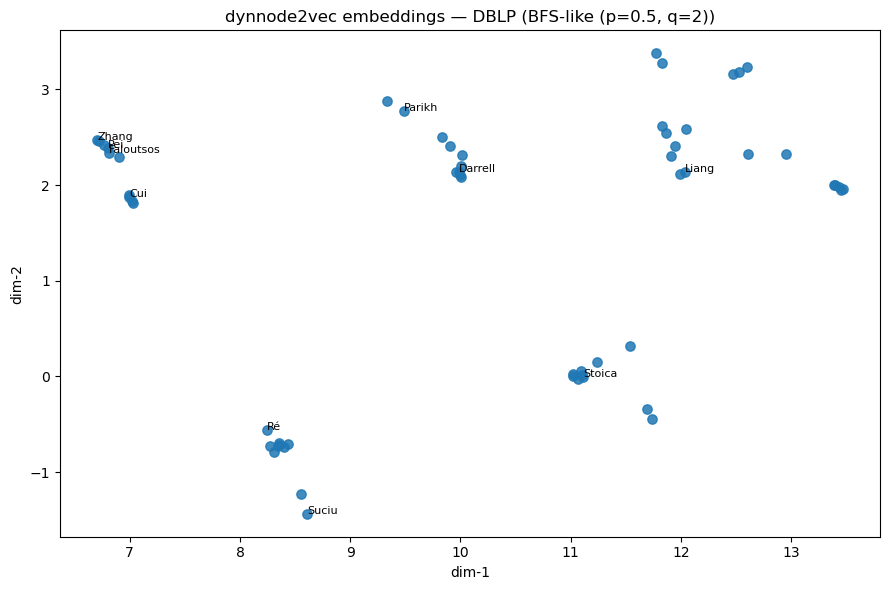

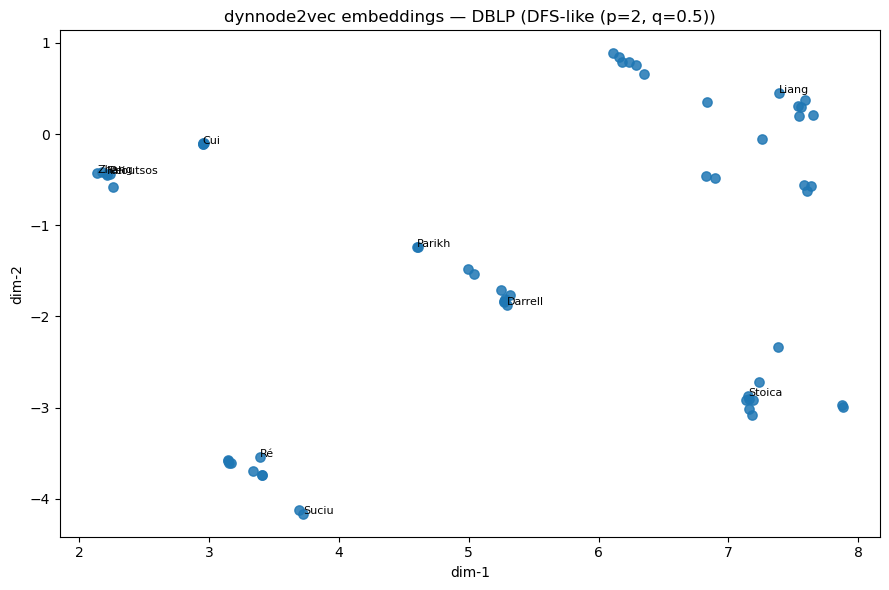

In [12]:
for model, title in [(model_bfs, 'BFS-like (p=0.5, q=2)'), (model_dfs, 'DFS-like (p=2, q=0.5)')]:
    nodes = [str(i) for i in range(len(authors)) if str(i) in model.wv]
    vectors = np.array([model.wv[n] for n in nodes])
    xy = TSNE(n_components=2, random_state=0, perplexity=min(30, len(vectors) - 1)).fit_transform(vectors)

    plt.figure(figsize=(9, 6))
    plt.scatter(xy[:, 0], xy[:, 1], s=45, alpha=0.85)
    deg = dict(graphs_12[-1].degree())
    for idx in sorted(deg, key=deg.get, reverse=True)[:10]:
        sid = str(idx)
        if sid in model.wv:
            j = nodes.index(sid)
            plt.annotate(authors[idx].split()[-1], xy[j], fontsize=8)
    plt.title(f'dynnode2vec embeddings — DBLP ({title})')
    plt.xlabel('dim-1'); plt.ylabel('dim-2')
    plt.tight_layout()
    plt.show()